In [6]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spikeinterface.full as si

try:
    from config import DATA_ROOT, DB_PATH
except Exception as exc:
    print(f"Warning: unable to import config paths from config.py: {exc}")
    DATA_ROOT = Path("F:/Data_Mice_IBL")
    DB_PATH = Path(r"F:\Data_Mice_IBL\full_db_all_rigs.feather")


def flatten_array_of_arrays(arr):
    out = []
    for x in arr:
        if isinstance(x, (list, np.ndarray)):
            out.extend(list(x))
        elif pd.notna(x):
            out.append(float(x))
    return np.array(out, dtype=float)


def extract_y_from_locations(locations, name="locations"):
    if isinstance(locations, dict):
        if "y" in locations:
            return np.asarray(locations["y"], dtype=float).reshape(-1)

        for key in ["sampled_locations_um", "unit_locations", "locations"]:
            if key in locations:
                arr = np.asarray(locations[key])

                if arr.dtype.names is not None:
                    if "y" in arr.dtype.names:
                        return np.asarray(arr["y"], dtype=float).reshape(-1)
                    raise ValueError(f"{name}: structured array has no 'y' field. Fields: {arr.dtype.names}")

                if arr.ndim == 2 and arr.shape[1] >= 2:
                    return np.asarray(arr[:, 1], dtype=float).reshape(-1)

                if arr.ndim == 1:
                    return np.asarray(arr, dtype=float).reshape(-1)

                raise ValueError(f"{name}: unsupported array shape in key '{key}': {arr.shape}")

        raise ValueError(f"{name}: unknown dict keys: {list(locations.keys())}")

    arr = np.asarray(locations)

    if arr.dtype.names is not None:
        if "y" in arr.dtype.names:
            return np.asarray(arr["y"], dtype=float).reshape(-1)
        raise ValueError(f"{name}: structured array has no 'y' field. Fields: {arr.dtype.names}")

    if arr.ndim == 2 and arr.shape[1] >= 2:
        return np.asarray(arr[:, 1], dtype=float).reshape(-1)

    if arr.ndim == 1:
        return np.asarray(arr, dtype=float).reshape(-1)

    raise ValueError(f"{name}: unsupported shape {arr.shape}")


def gaussian_kernel1d(sigma, radius=None):
    if sigma <= 0:
        return np.array([1.0], dtype=float)
    if radius is None:
        radius = max(1, int(3 * sigma))
    x = np.arange(-radius, radius + 1, dtype=float)
    k = np.exp(-(x ** 2) / (2 * sigma ** 2))
    k /= k.sum()
    return k


def gaussian_smooth_1d(arr, sigma, axis):
    if sigma <= 0:
        return arr
    kernel = gaussian_kernel1d(sigma)
    return np.apply_along_axis(lambda m: np.convolve(m, kernel, mode="same"), axis=axis, arr=arr)


def gaussian_smooth_reflect_1d(arr, sigma):
    if sigma <= 0:
        return arr.copy()
    kernel = gaussian_kernel1d(sigma)
    pad = len(kernel) // 2
    padded = np.pad(arr, pad_width=pad, mode="reflect")
    return np.convolve(padded, kernel, mode="valid")


def zscore_from_baseline(curve, time_centers, baseline_start, baseline_end):
    baseline_mask = (time_centers >= baseline_start) & (time_centers < baseline_end)
    if baseline_mask.sum() == 0:
        return np.full_like(curve, np.nan, dtype=float)
    baseline = curve[baseline_mask]
    mu = np.mean(baseline)
    sigma = np.std(baseline)
    if sigma < 1e-12:
        return curve - mu
    return (curve - mu) / sigma


def zscore_from_baseline_mask(curve, baseline_mask):
    baseline = curve[baseline_mask]
    mu = np.mean(baseline)
    sigma = np.std(baseline)
    if sigma < 1e-12:
        return curve - mu
    return (curve - mu) / sigma


def histogram_rate(times, bins):
    counts, _ = np.histogram(times, bins=bins)
    bin_width = np.diff(bins)[0]
    return counts / bin_width


def build_profiles_for_band(
    spike_times_beh_band,
    valid_bout_starts,
    valid_first_licks,
    valid_last_licks,
    pre_window_s,
    post_window_s,
    time_bin_s,
    n_bins_start_to_first,
    n_bins_first_to_last,
):
    pre_bins = np.arange(-pre_window_s, 0 + time_bin_s, time_bin_s)
    post_bins = np.arange(0, post_window_s + time_bin_s, time_bin_s)

    n_pre = len(pre_bins) - 1
    n_mid1 = n_bins_start_to_first
    n_mid2 = n_bins_first_to_last
    n_post = len(post_bins) - 1

    baseline_mask = np.r_[
        np.ones(n_pre, dtype=bool),
        np.zeros(n_mid1 + n_mid2 + n_post, dtype=bool)
    ]

    all_profiles_z = []

    for bout_start, first_lick, last_lick in zip(valid_bout_starts, valid_first_licks, valid_last_licks):
        pre_start = bout_start - pre_window_s
        pre_stop = bout_start
        pre_mask = (spike_times_beh_band >= pre_start) & (spike_times_beh_band < pre_stop)
        pre_times = spike_times_beh_band[pre_mask] - bout_start
        pre_rate = histogram_rate(pre_times, pre_bins)

        mid1_duration = first_lick - bout_start
        if mid1_duration <= 0:
            continue

        mid1_mask = (spike_times_beh_band >= bout_start) & (spike_times_beh_band < first_lick)
        mid1_times_norm = (spike_times_beh_band[mid1_mask] - bout_start) / mid1_duration
        mid1_bins = np.linspace(0, 1, n_mid1 + 1)
        mid1_rate = np.histogram(mid1_times_norm, bins=mid1_bins)[0] / (mid1_duration / n_mid1)

        mid2_duration = last_lick - first_lick
        if mid2_duration <= 0:
            continue

        mid2_mask = (spike_times_beh_band >= first_lick) & (spike_times_beh_band < last_lick)
        mid2_times_norm = (spike_times_beh_band[mid2_mask] - first_lick) / mid2_duration
        mid2_bins = np.linspace(0, 1, n_mid2 + 1)
        mid2_rate = np.histogram(mid2_times_norm, bins=mid2_bins)[0] / (mid2_duration / n_mid2)

        post_start = last_lick
        post_stop = last_lick + post_window_s
        post_mask = (spike_times_beh_band >= post_start) & (spike_times_beh_band < post_stop)
        post_times = spike_times_beh_band[post_mask] - last_lick
        post_rate = histogram_rate(post_times, post_bins)

        profile = np.concatenate([pre_rate, mid1_rate, mid2_rate, post_rate])
        profile_z = zscore_from_baseline_mask(profile, baseline_mask)
        all_profiles_z.append(profile_z)

    if len(all_profiles_z) == 0:
        raise ValueError("No bout profiles could be built for this depth band.")

    all_profiles_z = np.vstack(all_profiles_z)
    return (
        all_profiles_z,
        np.mean(all_profiles_z, axis=0),
        np.std(all_profiles_z, axis=0),
    )


def plot_heatmap(
    heatmap,
    time_bins,
    depth_bins,
    spike_density_smooth,
    depth_centers,
    bout_times=None,
    bout_color="#4FC3F7",
    title="Spike activity along probe",
):
    vmin = np.percentile(heatmap, 10)
    vmax = np.percentile(heatmap, 99)

    if vmax <= vmin:
        vmax = vmin + 1e-3

    fig, (ax0, ax1) = plt.subplots(
        1, 2,
        figsize=(13, 9),
        gridspec_kw={"width_ratios": [4, 1]},
        sharey=True
    )

    im = ax0.imshow(
        heatmap,
        aspect="auto",
        origin="lower",
        extent=[time_bins[0], time_bins[-1], depth_bins[0], depth_bins[-1]],
        cmap="magma",
        vmin=vmin,
        vmax=vmax
    )

    if bout_times is not None:
        for t in bout_times:
            ax0.axvline(t, color=bout_color, linewidth=0.9, alpha=0.85)

    ax0.set_title(title)
    ax0.set_xlabel("Time (s)")
    ax0.set_ylabel("Depth (µm)")

    cbar = plt.colorbar(im, ax=ax0)
    cbar.set_label("Spike rate")

    ax1.plot(spike_density_smooth, depth_centers, linewidth=2, color="black")
    ax1.fill_betweenx(depth_centers, 0, spike_density_smooth, alpha=0.3, color="gray")
    ax1.set_title("Spike density")
    ax1.set_xlabel("Spike count")
    ax1.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


In [7]:
# ==========================================================
# === CONFIG ===============================================
# ==========================================================

mouse = "VF074v3"
mouse_behavior = "VF074"
date = "2026_03_24"

base_folder = DATA_ROOT / mouse / date
rec_folder = base_folder / "Rec" / "probe00"
analyzer_folder = base_folder / "sorting_analyzer" / "probe00"
bombcell_csv = base_folder / "bombcell" / "probe00" / "bombcell_labels.csv"
affine_path = base_folder / "alignment_affine.json"
lf_cbin_path = rec_folder / "disabled_g0_t0.imec0.lf.cbin"
ap_cbin_path = rec_folder / "disabled_g0_t0.imec0.ap.cbin"

# fenêtre affichée en temps comportement
t_start = None
t_stop = None

# paramètres heatmap
time_bin_s = 1
depth_bin_um = 40
smooth_sigma_time = 1.0
smooth_sigma_depth = 1.0
smooth_sigma_spike_density = 1.5

bout_color = "#4FC3F7"


Loaded alignment: t_behavior = 1.00001609 * t_ephys + -6.73659817
Behavior bouts: 135
Rewarded licks: 252
Non-rewarded licks: 578
Invalid licks: 157
LFP file: disabled_g0_t0.imec0.lf.cbin
AP file : disabled_g0_t0.imec0.ap.cbin
Total spikes: 13157131
Spike locations loaded: (13157131,)
Good units from Bombcell: 142
Spikes kept from good units: 2598357


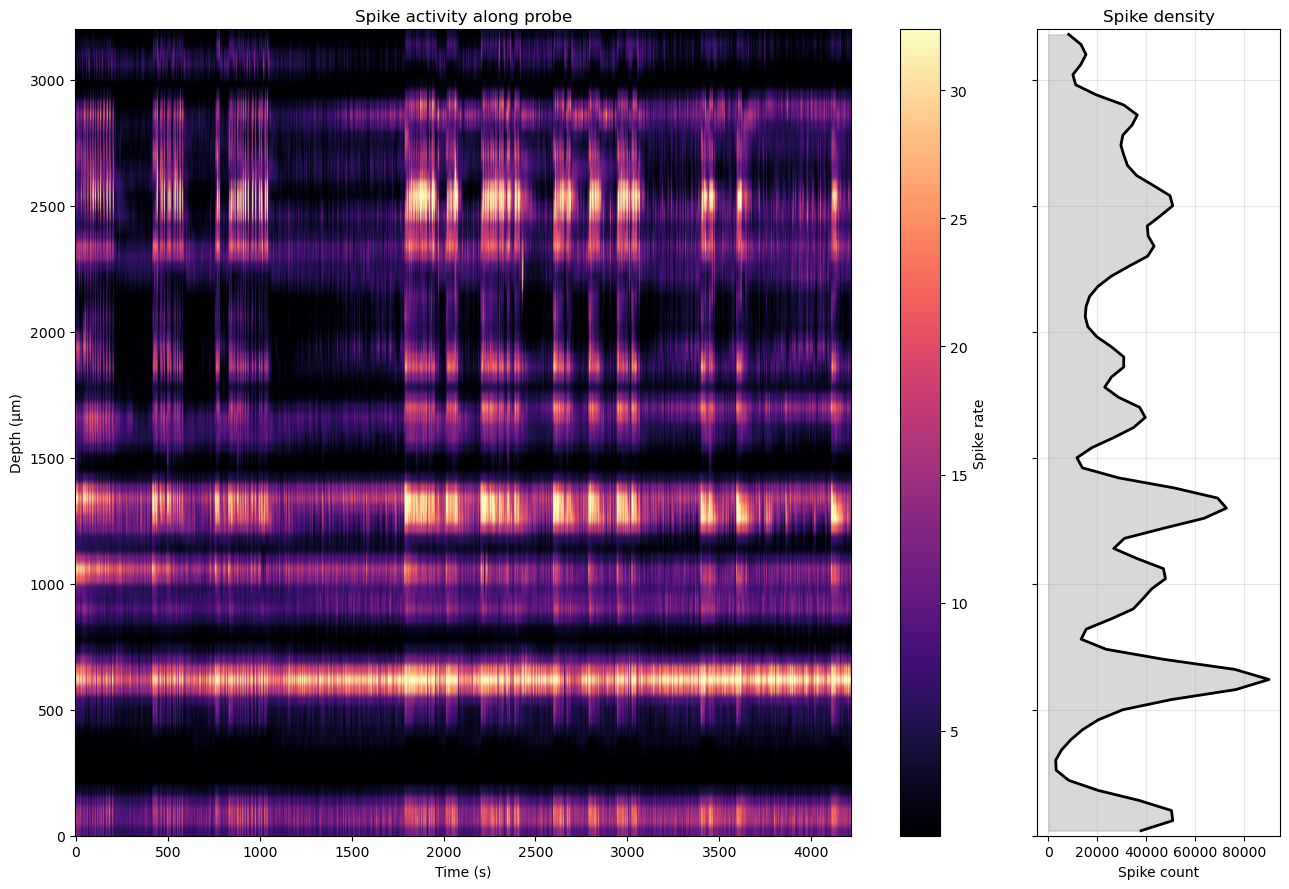

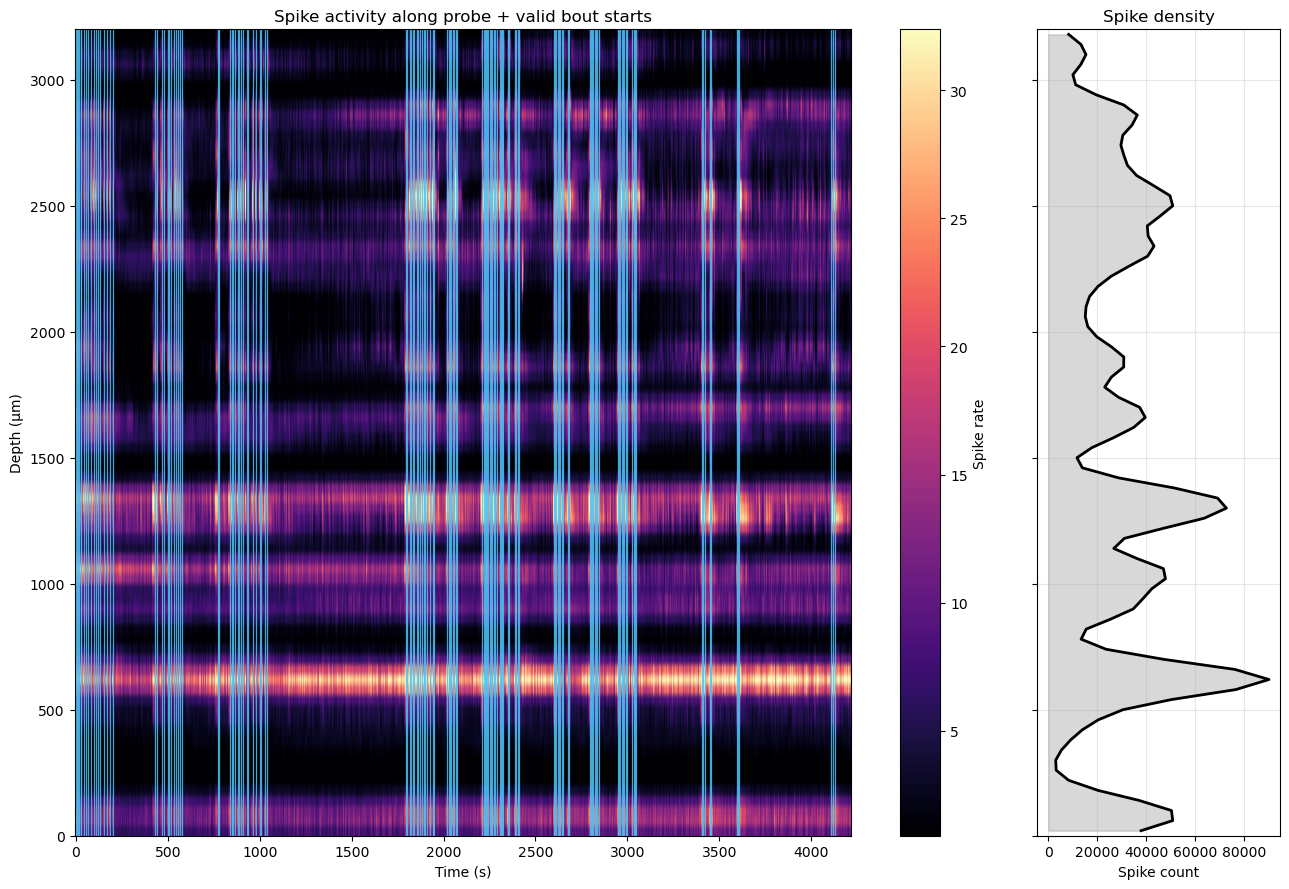

In [8]:
# ==========================================================
# === LOAD ALIGNMENT =======================================
# ==========================================================

with open(affine_path, "r", encoding="utf-8") as f:
    affine = json.load(f)

a = float(affine["a"])
b = float(affine["b"])

print(f"Loaded alignment: t_behavior = {a:.8f} * t_ephys + {b:.8f}")


# ==========================================================
# === LOAD BEHAVIOR ========================================
# ==========================================================

date_str = f"{date[:4]}-{date[5:7]}-{date[8:10]}"

df = pd.read_feather(DB_PATH)
row = df[(df["Mouse_ID"] == mouse_behavior) & (df["Date"] == date_str)]

if len(row) == 0:
    raise ValueError(f"No behavior entry found for {mouse_behavior} / {date_str}")

row = row.iloc[0]

bout_starts = np.asarray(row["Bout Start Times"], dtype=float)
lick_rewarded = flatten_array_of_arrays(row["Times Rewarded Licks"])
lick_nonrewarded = flatten_array_of_arrays(row["Times Non Rewarded Licks"])
lick_invalid = flatten_array_of_arrays(row["Times Invalid Licks"])

print(f"Behavior bouts: {len(bout_starts)}")
print(f"Rewarded licks: {len(lick_rewarded)}")
print(f"Non-rewarded licks: {len(lick_nonrewarded)}")
print(f"Invalid licks: {len(lick_invalid)}")


# ==========================================================
# === CHECK FILES ==========================================
# ==========================================================

if not lf_cbin_path.exists():
    raise FileNotFoundError(f"LFP cbin file not found:\n{lf_cbin_path}")

if not ap_cbin_path.exists():
    raise FileNotFoundError(f"AP cbin file not found:\n{ap_cbin_path}")

print(f"LFP file: {lf_cbin_path.name}")
print(f"AP file : {ap_cbin_path.name}")


# ==========================================================
# === LOAD SORTING + SPIKES ================================
# ==========================================================

analyzer = si.load_sorting_analyzer(analyzer_folder)
sorting = analyzer.sorting

unit_ids = np.asarray(sorting.unit_ids)
spike_vector = sorting.to_spike_vector()
spike_samples = spike_vector["sample_index"]
spike_unit_indices = spike_vector["unit_index"]

rec_ap = si.read_cbin_ibl(
    folder_path=rec_folder,
    cbin_file_path=ap_cbin_path,
    load_sync_channel=False,
    stream_name="ap",
)

fs_ap = rec_ap.get_sampling_frequency()
spike_times_ephys = spike_samples / fs_ap
spike_times_beh = a * spike_times_ephys + b

print(f"Total spikes: {len(spike_times_beh)}")


# ==========================================================
# === LOAD SPIKE LOCATIONS =================================
# ==========================================================

spike_locations = analyzer.get_extension("spike_locations").get_data()
spike_depths = extract_y_from_locations(spike_locations, name="spike_locations")

if len(spike_depths) != len(spike_times_beh):
    raise ValueError(
        f"Mismatch between number of spike depths ({len(spike_depths)}) "
        f"and number of spikes ({len(spike_times_beh)})"
    )

print(f"Spike locations loaded: {spike_depths.shape}")


# ==========================================================
# === SELECT GOOD UNITS IF AVAILABLE ========================
# ==========================================================

good_unit_ids = None

if bombcell_csv.exists():
    labels = pd.read_csv(bombcell_csv, index_col=0)
    if "bombcell_label" in labels.columns:
        good_unit_ids = labels.index[labels["bombcell_label"] == "good"].astype(int).to_numpy()
        print(f"Good units from Bombcell: {len(good_unit_ids)}")

if good_unit_ids is not None:
    good_mask_units = np.isin(unit_ids[spike_unit_indices], good_unit_ids)
    spike_times_beh = spike_times_beh[good_mask_units]
    spike_depths = spike_depths[good_mask_units]
    print(f"Spikes kept from good units: {len(spike_times_beh)}")
else:
    print("No Bombcell good-unit filter found, using all spikes.")


# ==========================================================
# === WINDOW ===============================================
# ==========================================================

if t_start is None:
    t_start = float(np.min(spike_times_beh))
if t_stop is None:
    t_stop = float(np.max(spike_times_beh))

mask = (
    (spike_times_beh >= t_start) &
    (spike_times_beh <= t_stop) &
    np.isfinite(spike_depths)
)

spike_times_plot = spike_times_beh[mask]
spike_depths_plot = spike_depths[mask]

bout_times_plot = bout_starts[(bout_starts >= t_start) & (bout_starts <= t_stop)]

if len(spike_times_plot) == 0:
    raise ValueError("No spikes in selected time window")


# ==========================================================
# === BUILD HEATMAP ========================================
# ==========================================================

depth_min = np.floor(np.min(spike_depths_plot) / depth_bin_um) * depth_bin_um
depth_max = np.ceil(np.max(spike_depths_plot) / depth_bin_um) * depth_bin_um + depth_bin_um

time_bins = np.arange(t_start, t_stop + time_bin_s, time_bin_s)
depth_bins = np.arange(depth_min, depth_max + depth_bin_um, depth_bin_um)

heatmap_counts, _, _ = np.histogram2d(
    spike_depths_plot,
    spike_times_plot,
    bins=[depth_bins, time_bins],
)

heatmap = heatmap_counts / time_bin_s
heatmap = gaussian_smooth_1d(heatmap, smooth_sigma_depth, axis=0)
heatmap = gaussian_smooth_1d(heatmap, smooth_sigma_time, axis=1)

depth_centers = 0.5 * (depth_bins[:-1] + depth_bins[1:])

spike_density, _ = np.histogram(spike_depths_plot, bins=depth_bins)
spike_density_smooth = gaussian_smooth_1d(
    spike_density.astype(float),
    sigma=smooth_sigma_spike_density,
    axis=0
)


# ==========================================================
# === FINAL PLOTS ==========================================
# ==========================================================

plot_heatmap(
    heatmap=heatmap,
    time_bins=time_bins,
    depth_bins=depth_bins,
    spike_density_smooth=spike_density_smooth,
    depth_centers=depth_centers,
    bout_times=None,
    bout_color=bout_color,
    title="Spike activity along probe",
)

plot_heatmap(
    heatmap=heatmap,
    time_bins=time_bins,
    depth_bins=depth_bins,
    spike_density_smooth=spike_density_smooth,
    depth_centers=depth_centers,
    bout_times=bout_times_plot,
    bout_color=bout_color,
    title="Spike activity along probe + valid bout starts",
)


Loaded alignment: t_behavior = 1.00001609 * t_ephys + -6.73659817
Total bouts found: 135
Valid bouts found: 101
Rewarded licks found: 252
Non-rewarded licks found: 578
Selected valid bouts:
[ 185.278016 1860.973024 2265.973024 2394.687008 3047.465024]
Total spikes: 13157131
Spike depths loaded: (13157131,)
Depth range: 21.1 to 3779.6 µm
Good units from Bombcell: 142
Spikes kept from good units: 2598357


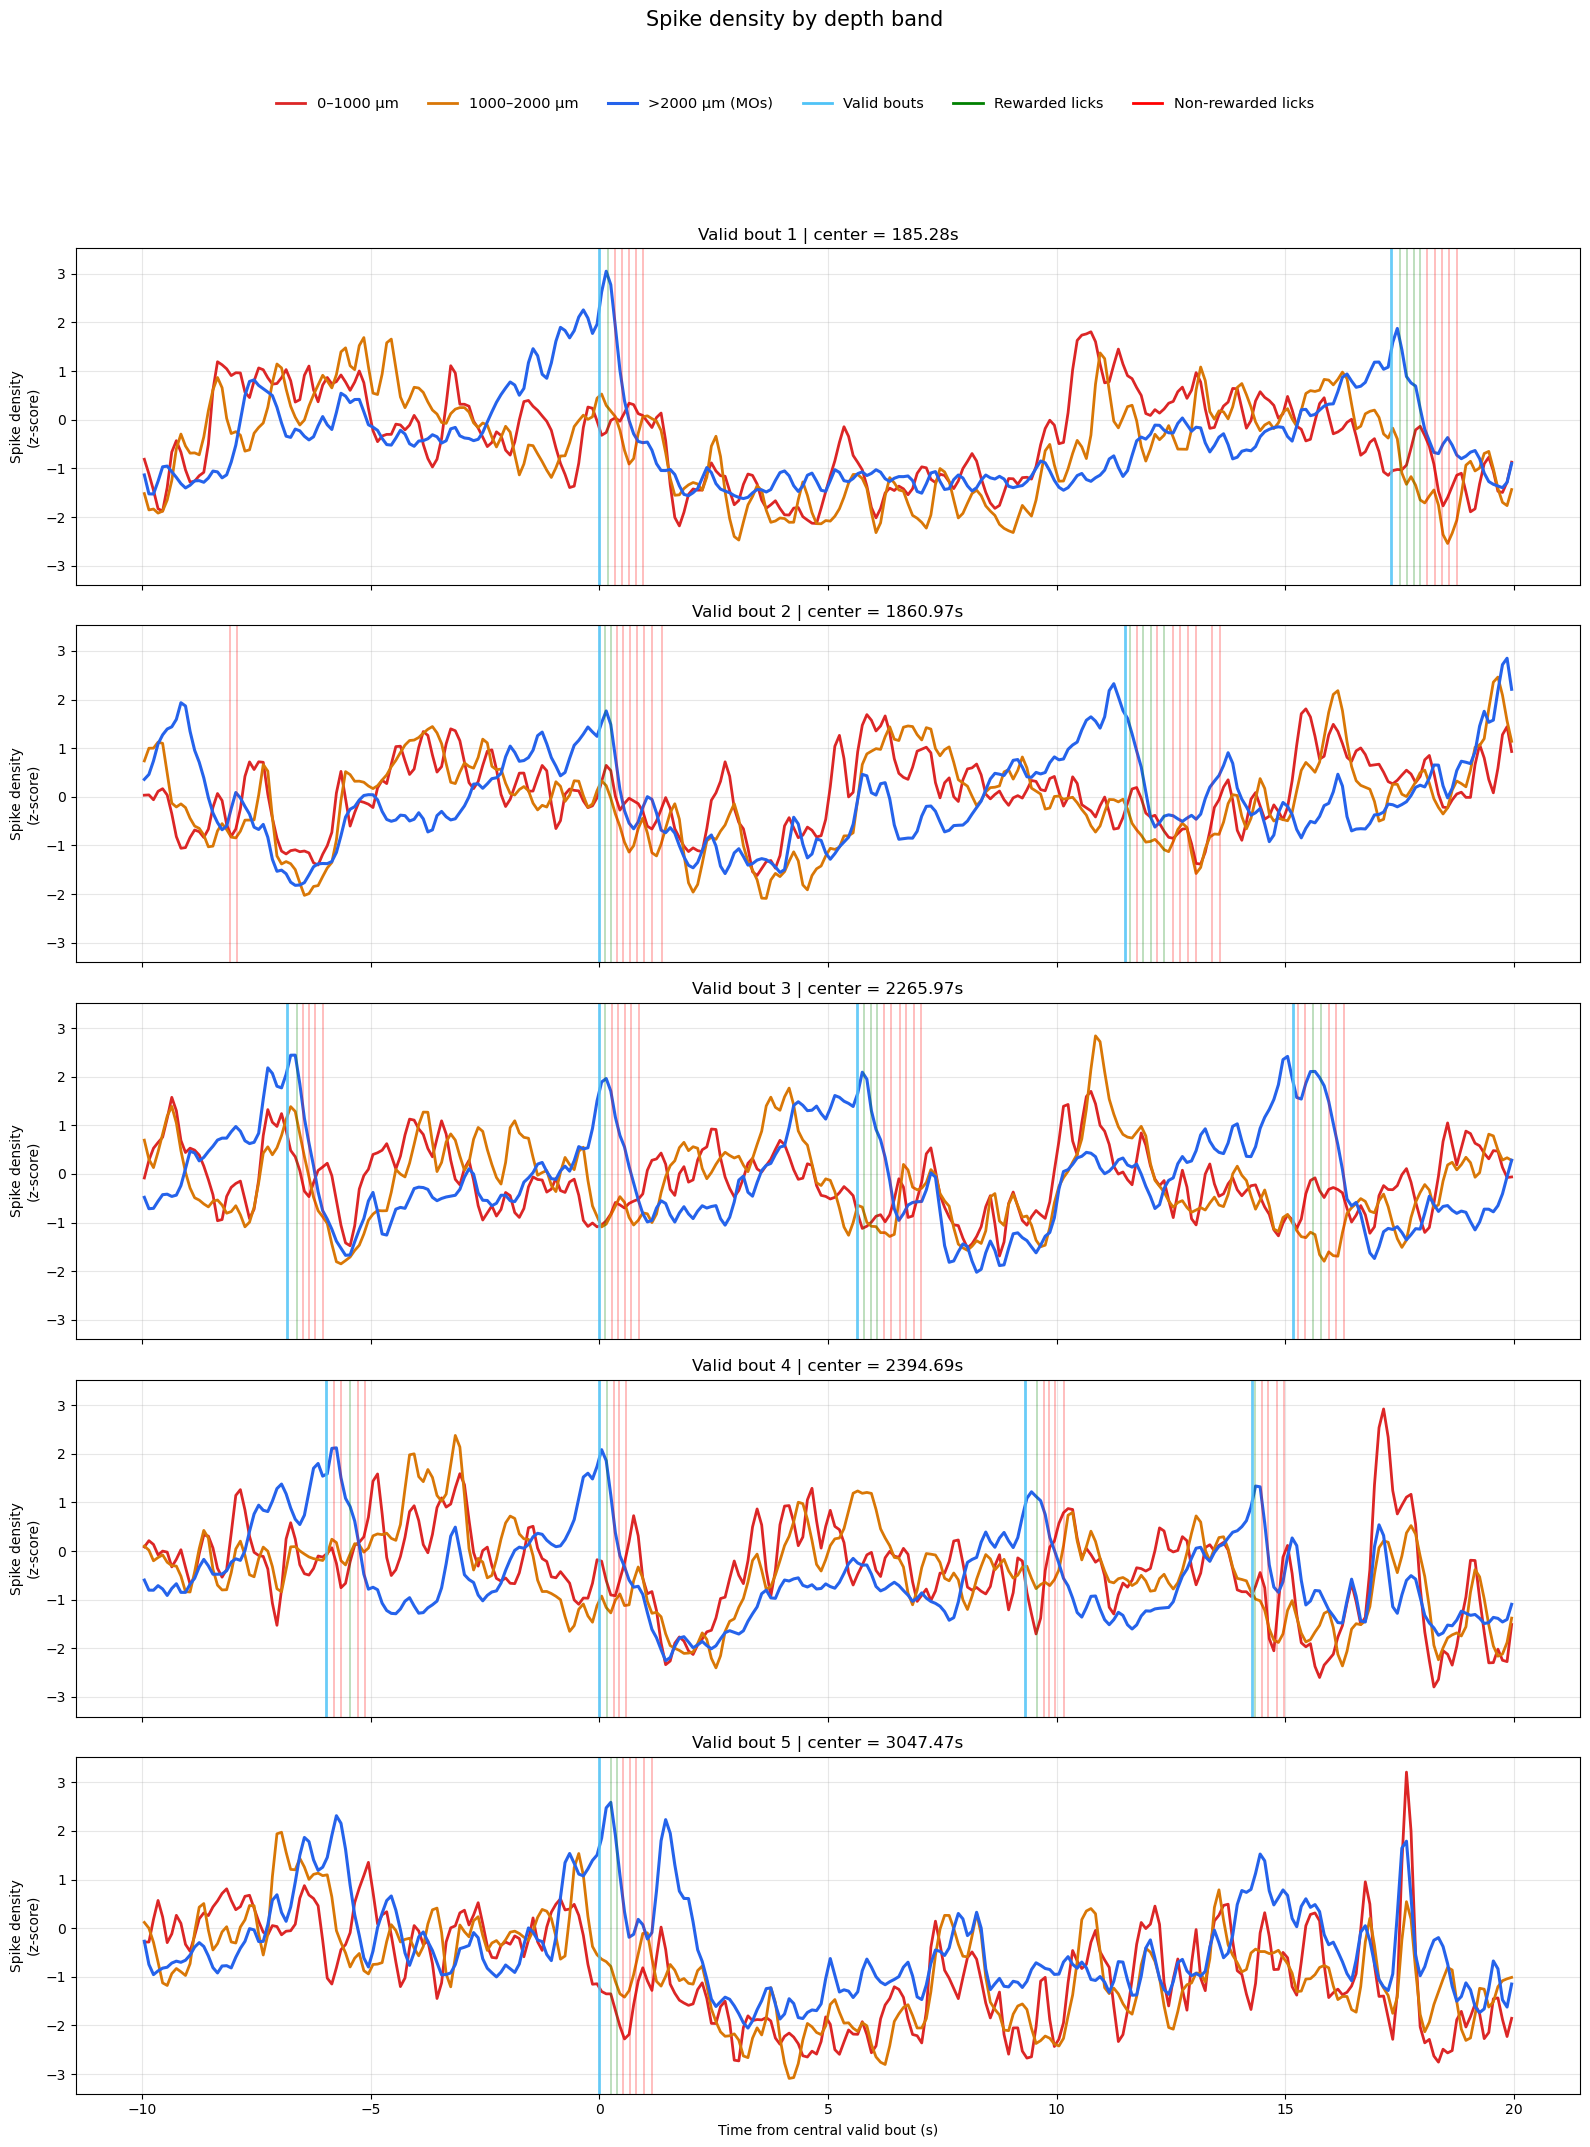

In [9]:
# ==========================================================
# === CONFIG ===============================================
# ==========================================================

mouse = "VF074v3"
mouse_behavior = "VF074"
date = "2026_03_24"

base_folder = DATA_ROOT / mouse / date
rec_folder = base_folder / "Rec" / "probe00"
analyzer_folder = base_folder / "sorting_analyzer" / "probe00"

affine_path = base_folder / "alignment_affine.json"
ap_cbin_path = rec_folder / "disabled_g0_t0.imec0.ap.cbin"
bombcell_csv = base_folder / "bombcell" / "probe00" / "bombcell_labels.csv"

# -------- bouts --------
n_bouts_to_plot = 5
random_seed = 42

# -------- fenêtre autour du bout --------
t_before = 10.0
t_after = 20.0

# -------- baseline pour z-score --------
baseline_start = -10.0
baseline_end = 0.0

# -------- binning temporel --------
time_bin_s = 0.1

# -------- smoothing --------
smooth_sigma_curve = 1.0

# -------- bandes de profondeur --------
band1_name = "0–1000 µm"
band2_name = "1000–2000 µm"
band3_name = ">2000 µm (MOs)"

# -------- couleurs --------
bout_color = "#4FC3F7"
rewarded_color = "green"
nonrewarded_color = "red"

band1_color = "#DC2626"
band2_color = "#D97706"
band3_color = "#2563EB"


# ==========================================================
# === LOAD ALIGNMENT =======================================
# ==========================================================

with open(affine_path, "r", encoding="utf-8") as f:
    affine = json.load(f)

a = float(affine["a"])
b = float(affine["b"])

print(f"Loaded alignment: t_behavior = {a:.8f} * t_ephys + {b:.8f}")


# ==========================================================
# === LOAD BEHAVIOR ========================================
# ==========================================================

date_str = f"{date[:4]}-{date[5:7]}-{date[8:10]}"

df = pd.read_feather(DB_PATH)
row = df[(df["Mouse_ID"] == mouse_behavior) & (df["Date"] == date_str)]

if len(row) == 0:
    raise ValueError(f"No behavior entry found for {mouse_behavior} / {date_str}")

row = row.iloc[0]

bout_starts = np.asarray(row["Bout Start Times"], dtype=float)
correct_bouts = np.asarray(row["Correct Bouts"], dtype=bool)

if len(correct_bouts) != len(bout_starts):
    raise ValueError(
        f"Mismatch between Correct Bouts ({len(correct_bouts)}) "
        f"and Bout Start Times ({len(bout_starts)})"
    )

valid_bout_starts = bout_starts[correct_bouts]

lick_rewarded = flatten_array_of_arrays(row["Times Rewarded Licks"])
lick_nonrewarded = flatten_array_of_arrays(row["Times Non Rewarded Licks"])

print(f"Total bouts found: {len(bout_starts)}")
print(f"Valid bouts found: {len(valid_bout_starts)}")
print(f"Rewarded licks found: {len(lick_rewarded)}")
print(f"Non-rewarded licks found: {len(lick_nonrewarded)}")


# ==========================================================
# === SELECT 5 RANDOM VALID BOUTS ==========================
# ==========================================================

if len(valid_bout_starts) == 0:
    raise ValueError("No valid bouts found.")

rng = np.random.default_rng(random_seed)
n_keep = min(n_bouts_to_plot, len(valid_bout_starts))
selected_bouts = np.sort(rng.choice(valid_bout_starts, size=n_keep, replace=False))

print("Selected valid bouts:")
print(selected_bouts)


# ==========================================================
# === LOAD SPIKES ==========================================
# ==========================================================

analyzer = si.load_sorting_analyzer(analyzer_folder)
sorting = analyzer.sorting

unit_ids = np.asarray(sorting.unit_ids)

spike_vector = sorting.to_spike_vector()
spike_samples = spike_vector["sample_index"]
spike_unit_indices = spike_vector["unit_index"]

rec_ap = si.read_cbin_ibl(
    folder_path=rec_folder,
    cbin_file_path=ap_cbin_path,
    load_sync_channel=False,
    stream_name="ap",
)

fs_ap = rec_ap.get_sampling_frequency()
spike_times_ephys = spike_samples / fs_ap
spike_times_beh = a * spike_times_ephys + b

print(f"Total spikes: {len(spike_times_beh)}")


# ==========================================================
# === LOAD SPIKE DEPTHS ====================================
# ==========================================================

spike_locations = analyzer.get_extension("spike_locations").get_data()
spike_depths = extract_y_from_locations(spike_locations, name="spike_locations")

if len(spike_depths) != len(spike_times_beh):
    raise ValueError(
        f"Mismatch between number of spike depths ({len(spike_depths)}) "
        f"and number of spikes ({len(spike_times_beh)})"
    )

print(f"Spike depths loaded: {spike_depths.shape}")
print(f"Depth range: {spike_depths.min():.1f} to {spike_depths.max():.1f} µm")


# ==========================================================
# === FILTER GOOD UNITS IF AVAILABLE ========================
# ==========================================================

if bombcell_csv.exists():
    labels = pd.read_csv(bombcell_csv, index_col=0)
    if "bombcell_label" in labels.columns:
        good_unit_ids = labels.index[labels["bombcell_label"] == "good"].astype(int).to_numpy()
        good_mask_units = np.isin(unit_ids[spike_unit_indices], good_unit_ids)
        spike_times_beh = spike_times_beh[good_mask_units]
        spike_depths = spike_depths[good_mask_units]
        print(f"Good units from Bombcell: {len(good_unit_ids)}")
        print(f"Spikes kept from good units: {len(spike_times_beh)}")
else:
    print("No Bombcell good-unit filter found, using all spikes.")


# ==========================================================
# === PREPARE TIME AXIS ====================================
# ==========================================================

rel_time_bins = np.arange(-t_before, t_after + time_bin_s, time_bin_s)
time_centers = 0.5 * (rel_time_bins[:-1] + rel_time_bins[1:])


# ==========================================================
# === PLOT 5 RANDOM VALID BOUTS =============================
# ==========================================================

ncols = 1
nrows = len(selected_bouts)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(16, 4.2 * nrows),
    sharex=True,
    sharey=True
)

axes = np.atleast_1d(axes).ravel()

for i, bout_t in enumerate(selected_bouts):
    ax = axes[i]

    win_start = bout_t - t_before
    win_stop = bout_t + t_after

    spike_mask = (spike_times_beh >= win_start) & (spike_times_beh <= win_stop)
    local_spike_times = spike_times_beh[spike_mask] - bout_t
    local_spike_depths = spike_depths[spike_mask]

    mask_band1 = (local_spike_depths >= 0) & (local_spike_depths < 1000)
    mask_band2 = (local_spike_depths >= 1000) & (local_spike_depths < 2000)
    mask_band3 = local_spike_depths >= 2000

    counts1, _ = np.histogram(local_spike_times[mask_band1], bins=rel_time_bins)
    counts2, _ = np.histogram(local_spike_times[mask_band2], bins=rel_time_bins)
    counts3, _ = np.histogram(local_spike_times[mask_band3], bins=rel_time_bins)

    rate1 = counts1 / time_bin_s
    rate2 = counts2 / time_bin_s
    rate3 = counts3 / time_bin_s

    rate1_z = zscore_from_baseline(rate1, time_centers, baseline_start, baseline_end)
    rate2_z = zscore_from_baseline(rate2, time_centers, baseline_start, baseline_end)
    rate3_z = zscore_from_baseline(rate3, time_centers, baseline_start, baseline_end)

    rate1_s = gaussian_smooth_1d(rate1_z, smooth_sigma_curve, axis=0)
    rate2_s = gaussian_smooth_1d(rate2_z, smooth_sigma_curve, axis=0)
    rate3_s = gaussian_smooth_1d(rate3_z, smooth_sigma_curve, axis=0)

    valid_bout_mask = (valid_bout_starts >= win_start) & (valid_bout_starts <= win_stop)
    local_valid_bouts = valid_bout_starts[valid_bout_mask] - bout_t

    reward_mask = (lick_rewarded >= win_start) & (lick_rewarded <= win_stop)
    local_rewarded = lick_rewarded[reward_mask] - bout_t

    nonreward_mask = (lick_nonrewarded >= win_start) & (lick_nonrewarded <= win_stop)
    local_nonrewarded = lick_nonrewarded[nonreward_mask] - bout_t

    ax.plot(time_centers, rate1_s, color=band1_color, linewidth=2.0)
    ax.plot(time_centers, rate2_s, color=band2_color, linewidth=2.0)
    ax.plot(time_centers, rate3_s, color=band3_color, linewidth=2.2)

    for t in local_valid_bouts:
        ax.axvline(t, color=bout_color, linewidth=2.0, alpha=0.85)

    for t in local_rewarded:
        ax.axvline(t, color=rewarded_color, linewidth=1.2, alpha=0.30)

    for t in local_nonrewarded:
        ax.axvline(t, color=nonrewarded_color, linewidth=1.2, alpha=0.30)

    ax.set_title(f"Valid bout {i+1} | center = {bout_t:.2f}s", fontsize=12)
    ax.grid(alpha=0.3)

for ax in axes:
    ax.set_ylabel("Spike density\n(z-score)")

axes[-1].set_xlabel("Time from central valid bout (s)")

handles = [
    plt.Line2D([0], [0], color=band1_color, lw=2.0, label=band1_name),
    plt.Line2D([0], [0], color=band2_color, lw=2.0, label=band2_name),
    plt.Line2D([0], [0], color=band3_color, lw=2.2, label=band3_name),
    plt.Line2D([0], [0], color=bout_color, lw=2.0, label="Valid bouts"),
    plt.Line2D([0], [0], color=rewarded_color, lw=2.0, label="Rewarded licks"),
    plt.Line2D([0], [0], color=nonrewarded_color, lw=2.0, label="Non-rewarded licks"),
]

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.985),
    ncol=6,
    frameon=False,
    fontsize=10.5
)

plt.suptitle(
    "Spike density by depth band",
    y=1.02,
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


Loaded alignment: t_behavior = 1.00001609 * t_ephys + -6.73659817
Total bouts: 135
Valid bouts after filtering: 100
Total spikes before filtering: 13157131
Good units from Bombcell: 142
Spikes kept from good units: 2598357
Spikes 0-1000 µm: 829793
Spikes 1000-2000 µm: 915518
Spikes >2000 µm (MOs): 853046
Bouts used for band 1: 100
Bouts used for band 2: 100
Bouts used for band 3: 100


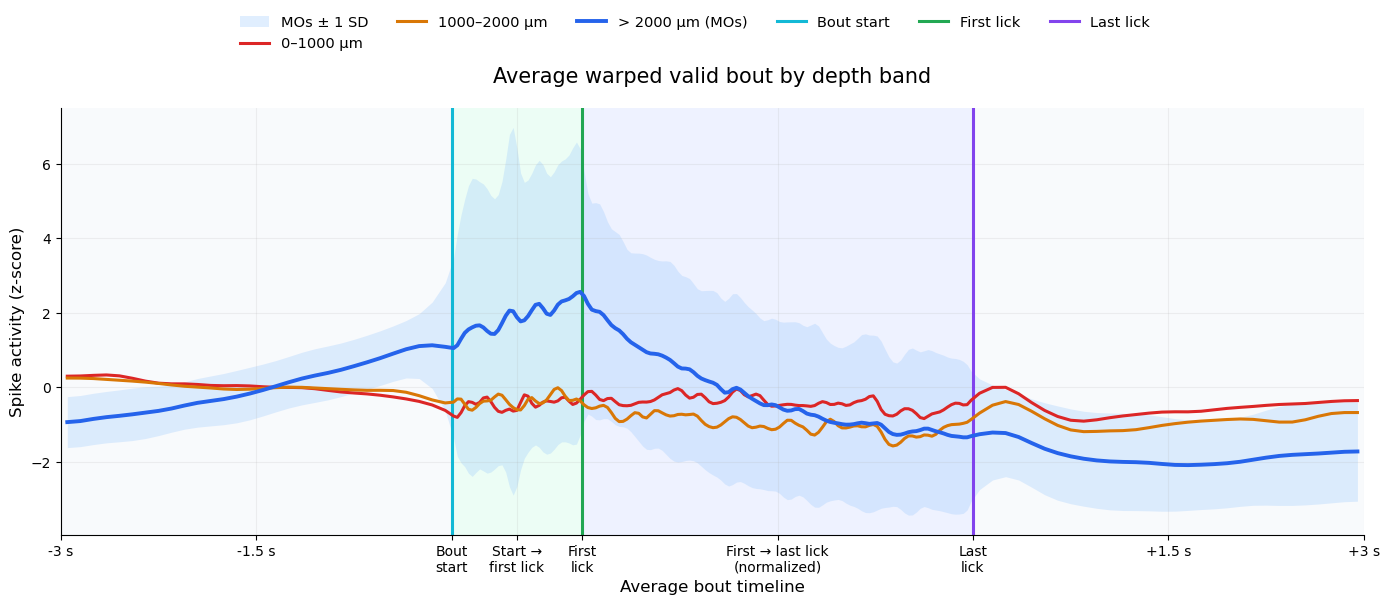

In [10]:
# ==========================================================
# === CONFIG ===============================================
# ==========================================================

mouse = "VF074v3"
mouse_behavior = "VF074"
date = "2026_03_24"

base_folder = DATA_ROOT / mouse / date
rec_folder = base_folder / "Rec" / "probe00"
analyzer_folder = base_folder / "sorting_analyzer" / "probe00"

affine_path = base_folder / "alignment_affine.json"
ap_cbin_path = rec_folder / "disabled_g0_t0.imec0.ap.cbin"
bombcell_csv = base_folder / "bombcell" / "probe00" / "bombcell_labels.csv"

# -------- fenêtres fixes --------
pre_window_s = 3.0
post_window_s = 3.0

# -------- résolution --------
time_bin_s = 0.1
smooth_sigma = 1.4

# -------- warping des zones --------
n_bins_start_to_first = 35
n_bins_first_to_last = 100

# -------- bandes de profondeur --------
depth_band_1 = (0.0, 1000.0)
depth_band_2 = (1000.0, 2000.0)
depth_band_3 = (2000.0, np.inf)

# -------- style --------
color_band_1 = "#DC2626"
color_band_2 = "#D97706"
color_band_3 = "#2563EB"
std_color_band_3 = "#93C5FD"

start_color = "#06B6D4"
firstlick_color = "#16A34A"
endlick_color = "#7C3AED"

bg_pre = "#F8FAFC"
bg_mid1 = "#ECFDF5"
bg_mid2 = "#EEF2FF"
bg_post = "#F8FAFC"


# ==========================================================
# === LOAD ALIGNMENT =======================================
# ==========================================================

with open(affine_path, "r", encoding="utf-8") as f:
    affine = json.load(f)

a = float(affine["a"])
b = float(affine["b"])

print(f"Loaded alignment: t_behavior = {a:.8f} * t_ephys + {b:.8f}")


# ==========================================================
# === LOAD BEHAVIOR ========================================
# ==========================================================

date_str = f"{date[:4]}-{date[5:7]}-{date[8:10]}"

df = pd.read_feather(DB_PATH)
row = df[(df["Mouse_ID"] == mouse_behavior) & (df["Date"] == date_str)]

if len(row) == 0:
    raise ValueError(f"No behavior entry found for {mouse_behavior} / {date_str}")

row = row.iloc[0]

bout_starts = np.asarray(row["Bout Start Times"], dtype=float)
correct_bouts = np.asarray(row["Correct Bouts"], dtype=bool)
time_first_lick = np.asarray(row["Time First Lick"], dtype=float)
time_last_lick = np.asarray(row["Time Last Lick"], dtype=float)

if len(correct_bouts) != len(bout_starts):
    raise ValueError(
        f"Mismatch between Correct Bouts ({len(correct_bouts)}) and Bout Start Times ({len(bout_starts)})"
    )

if len(time_first_lick) != len(bout_starts):
    raise ValueError(
        f"Mismatch between Time First Lick ({len(time_first_lick)}) and Bout Start Times ({len(bout_starts)})"
    )

if len(time_last_lick) != len(bout_starts):
    raise ValueError(
        f"Mismatch between Time Last Lick ({len(time_last_lick)}) and Bout Start Times ({len(bout_starts)})"
    )

valid_bout_starts = bout_starts[correct_bouts]
valid_first_licks = time_first_lick[correct_bouts]
valid_last_licks = time_last_lick[correct_bouts]

valid_mask = (
    np.isfinite(valid_bout_starts)
    & np.isfinite(valid_first_licks)
    & np.isfinite(valid_last_licks)
    & (valid_first_licks > valid_bout_starts)
    & (valid_last_licks > valid_first_licks)
)

valid_bout_starts = valid_bout_starts[valid_mask]
valid_first_licks = valid_first_licks[valid_mask]
valid_last_licks = valid_last_licks[valid_mask]

print(f"Total bouts: {len(bout_starts)}")
print(f"Valid bouts after filtering: {len(valid_bout_starts)}")

if len(valid_bout_starts) == 0:
    raise ValueError("No valid bouts available after filtering.")


# ==========================================================
# === LOAD SPIKES ==========================================
# ==========================================================

analyzer = si.load_sorting_analyzer(analyzer_folder)
sorting = analyzer.sorting

unit_ids = np.asarray(sorting.unit_ids)

spike_vector = sorting.to_spike_vector()
spike_samples = spike_vector["sample_index"]
spike_unit_indices = spike_vector["unit_index"]

rec_ap = si.read_cbin_ibl(
    folder_path=rec_folder,
    cbin_file_path=ap_cbin_path,
    load_sync_channel=False,
    stream_name="ap",
)

fs_ap = rec_ap.get_sampling_frequency()
spike_times_ephys = spike_samples / fs_ap
spike_times_beh = a * spike_times_ephys + b

print(f"Total spikes before filtering: {len(spike_times_beh)}")


# ==========================================================
# === LOAD SPIKE DEPTHS ====================================
# ==========================================================

spike_locations = analyzer.get_extension("spike_locations").get_data()
spike_depths = extract_y_from_locations(spike_locations, name="spike_locations")

if len(spike_depths) != len(spike_times_beh):
    raise ValueError(
        f"Mismatch between spike depths ({len(spike_depths)}) and spikes ({len(spike_times_beh)})"
    )


# ==========================================================
# === FILTER GOOD UNITS IF AVAILABLE ========================
# ==========================================================

if bombcell_csv.exists():
    labels = pd.read_csv(bombcell_csv, index_col=0)
    if "bombcell_label" in labels.columns:
        good_unit_ids = labels.index[labels["bombcell_label"] == "good"].astype(int).to_numpy()
        good_mask_units = np.isin(unit_ids[spike_unit_indices], good_unit_ids)
        spike_times_beh = spike_times_beh[good_mask_units]
        spike_depths = spike_depths[good_mask_units]
        print(f"Good units from Bombcell: {len(good_unit_ids)}")
        print(f"Spikes kept from good units: {len(spike_times_beh)}")
else:
    print("No Bombcell filter found, using all spikes.")


# ==========================================================
# === SPLIT DEPTH BANDS ====================================
# ==========================================================

mask_band_1 = (spike_depths >= depth_band_1[0]) & (spike_depths < depth_band_1[1])
mask_band_2 = (spike_depths >= depth_band_2[0]) & (spike_depths < depth_band_2[1])
mask_band_3 = spike_depths >= depth_band_3[0]

spike_times_beh_1 = spike_times_beh[mask_band_1]
spike_times_beh_2 = spike_times_beh[mask_band_2]
spike_times_beh_3 = spike_times_beh[mask_band_3]

print(f"Spikes 0-1000 µm: {len(spike_times_beh_1)}")
print(f"Spikes 1000-2000 µm: {len(spike_times_beh_2)}")
print(f"Spikes >2000 µm (MOs): {len(spike_times_beh_3)}")


# ==========================================================
# === BUILD WARPED PROFILES FOR EACH BAND ==================
# ==========================================================

profiles_1, mean_1, std_1 = build_profiles_for_band(
    spike_times_beh_1,
    valid_bout_starts,
    valid_first_licks,
    valid_last_licks,
    pre_window_s,
    post_window_s,
    time_bin_s,
    n_bins_start_to_first,
    n_bins_first_to_last,
)

profiles_2, mean_2, std_2 = build_profiles_for_band(
    spike_times_beh_2,
    valid_bout_starts,
    valid_first_licks,
    valid_last_licks,
    pre_window_s,
    post_window_s,
    time_bin_s,
    n_bins_start_to_first,
    n_bins_first_to_last,
)

profiles_3, mean_3, std_3 = build_profiles_for_band(
    spike_times_beh_3,
    valid_bout_starts,
    valid_first_licks,
    valid_last_licks,
    pre_window_s,
    post_window_s,
    time_bin_s,
    n_bins_start_to_first,
    n_bins_first_to_last,
)

mean_1_s = gaussian_smooth_reflect_1d(mean_1, smooth_sigma)
mean_2_s = gaussian_smooth_reflect_1d(mean_2, smooth_sigma)
mean_3_s = gaussian_smooth_reflect_1d(mean_3, smooth_sigma)
std_3_s = gaussian_smooth_reflect_1d(std_3, smooth_sigma)

print(f"Bouts used for band 1: {profiles_1.shape[0]}")
print(f"Bouts used for band 2: {profiles_2.shape[0]}")
print(f"Bouts used for band 3: {profiles_3.shape[0]}")


# ==========================================================
# === BUILD X AXIS WITH 4 VISUAL ZONES =====================
# ==========================================================

n_pre = int(pre_window_s / time_bin_s)
n_mid1 = n_bins_start_to_first
n_mid2 = n_bins_first_to_last
n_post = int(post_window_s / time_bin_s)

mid1_width = 1.0 / 3.0
mid2_start = 1.0 + mid1_width
post_start_x = mid2_start + 1.0
x_end = post_start_x + 1.0

x_pre = np.linspace(0.0, 1.0, n_pre, endpoint=False) + 0.5 / n_pre
x_mid1 = np.linspace(1.0, 1.0 + mid1_width, n_mid1, endpoint=False) + 0.5 * (mid1_width / n_mid1)
x_mid2 = np.linspace(mid2_start, post_start_x, n_mid2, endpoint=False) + 0.5 * (1.0 / n_mid2)
x_post = np.linspace(post_start_x, x_end, n_post, endpoint=False) + 0.5 * (1.0 / n_post)

x_all = np.concatenate([x_pre, x_mid1, x_mid2, x_post])


# ==========================================================
# === PLOT ================================================
# ==========================================================

fig, ax = plt.subplots(figsize=(14, 6.2))

ax.axvspan(0.0, 1.0, color=bg_pre, alpha=1.0, zorder=0)
ax.axvspan(1.0, 1.0 + mid1_width, color=bg_mid1, alpha=1.0, zorder=0)
ax.axvspan(mid2_start, post_start_x, color=bg_mid2, alpha=1.0, zorder=0)
ax.axvspan(post_start_x, x_end, color=bg_post, alpha=1.0, zorder=0)

ax.fill_between(
    x_all,
    mean_3_s - std_3_s,
    mean_3_s + std_3_s,
    color=std_color_band_3,
    alpha=0.28,
    linewidth=0,
    label="MOs ± 1 SD",
    zorder=1,
)

ax.plot(x_all, mean_1_s, color=color_band_1, linewidth=2.2, label="0–1000 µm", zorder=3)
ax.plot(x_all, mean_2_s, color=color_band_2, linewidth=2.2, label="1000–2000 µm", zorder=3)
ax.plot(x_all, mean_3_s, color=color_band_3, linewidth=2.8, label="> 2000 µm (MOs)", zorder=4)

ax.axvline(1.0, color=start_color, linewidth=2.2, alpha=0.95, label="Bout start")
ax.axvline(1.0 + mid1_width, color=firstlick_color, linewidth=2.2, alpha=0.95, label="First lick")
ax.axvline(post_start_x, color=endlick_color, linewidth=2.2, alpha=0.95, label="Last lick")

ax.set_xlim(0.0, x_end)
ax.set_xticks(
    [0.0, 0.5, 1.0, 1.0 + mid1_width / 2, 1.0 + mid1_width, (mid2_start + post_start_x) / 2, post_start_x, post_start_x + 0.5, x_end],
    [
        "-3 s",
        "-1.5 s",
        "Bout\nstart",
        "Start →\nfirst lick",
        "First\nlick",
        "First → last lick\n(normalized)",
        "Last\nlick",
        "+1.5 s",
        "+3 s",
    ]
)

ax.set_xlabel("Average bout timeline", fontsize=12)
ax.set_ylabel("Spike activity (z-score)", fontsize=12)
ax.set_title("Average warped valid bout by depth band", fontsize=15, pad=18)

ax.grid(alpha=0.18, linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=6,
    frameon=False,
    fontsize=10.5,
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()
